In [1]:
import pandas as pd
import numpy as np
import torch
import transformers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from transformers import AutoModel, BertTokenizerFast, DistilBertTokenizerFast, AutoTokenizer, RobertaForSequenceClassification, AutoModelForSequenceClassification
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler
import torch.nn as nn
from sklearn.utils.class_weight import compute_class_weight
from tqdm.notebook import tqdm
import os
import shap
import spacy
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import f1_score
from collections import defaultdict, Counter
import random
import pickle
import torch.nn.functional as F
import re

In [13]:
!pip install -U bitsandbytes

In [14]:
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

In [15]:
model_name = "llama"

In [16]:
nlp = spacy.load("en_core_web_sm")

In [17]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Read Data

In [19]:
os.chdir('/content/drive/My Drive/NLP-Letters-V2/notebooks/')
df = pd.read_csv('../data/combined_letters_degendered.csv')

# Create Training and Test Sets

In [20]:
train_text, temp_text, train_labels, temp_labels = train_test_split(df['full_text'], df['label'], test_size=0.2, random_state=42, stratify=df['label'])

val_text, test_text, val_labels, test_labels = train_test_split(temp_text, temp_labels, test_size=0.5, random_state=42, stratify=temp_labels)

In [22]:
tokenizer = AutoTokenizer.from_pretrained("../saved_models/merged_llama2_classifier")

model = AutoModelForSequenceClassification.from_pretrained(
    "../saved_models/merged_llama2_classifier",
    device_map="auto",
    # load_in_8bit=True
)

Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

In [23]:
tokens_train = tokenizer.batch_encode_plus(
    train_text.tolist(),
    max_length=2048,
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_val = tokenizer.batch_encode_plus(
    val_text.tolist(),
    max_length=2048,
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

tokens_test = tokenizer.batch_encode_plus(
    test_text.tolist(),
    max_length=2048,
    padding='max_length',
    truncation=True,
    return_tensors="pt"
)

In [24]:
train_seq = torch.tensor(tokens_train['input_ids'])
train_mask = torch.tensor(tokens_train['attention_mask'])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val['input_ids'])
val_mask = torch.tensor(tokens_val['attention_mask'])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test['input_ids'])
test_mask = torch.tensor(tokens_test['attention_mask'])
test_y = torch.tensor(test_labels.tolist())

/tmp/ipython-input-2686642901.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_seq = torch.tensor(tokens_train['input_ids'])
/tmp/ipython-input-2686642901.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_mask = torch.tensor(tokens_train['attention_mask'])
/tmp/ipython-input-2686642901.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_seq = torch.tensor(tokens_val['input_ids'])
/tmp/ipython-input-2686642901.py:6: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or 

# Test Model

In [25]:
# Clear GPU memory
torch.cuda.empty_cache()

# Load tokenizer and set pad_token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token  # LLaMA usually uses EOS token for padding

# Set pad_token_id in config explicitly
model.config.pad_token_id = tokenizer.pad_token_id

model.eval()

# all_preds = []
# all_labels = []

# with torch.inference_mode():
#     for batch in tqdm(test_dataloader, desc="Evaluating"):
#         input_ids, attention_mask, labels = batch
#         input_ids = input_ids.to(model.device)
#         attention_mask = attention_mask.to(model.device)

#         outputs = model(input_ids=input_ids, attention_mask=attention_mask)
#         logits = outputs.logits
#         preds = torch.argmax(logits, dim=1)

#         all_preds.extend(preds.cpu().numpy())
#         all_labels.extend(labels.cpu().numpy())

# print("Classification Report:\n", classification_report(all_labels, all_preds))
# print("Confusion Matrix:\n", confusion_matrix(all_labels, all_preds))

LlamaForSequenceClassification(
  (model): LlamaModel(
    (embed_tokens): Embedding(32000, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (v_proj): Linear(in_features=4096, out_features=4096, bias=False)
          (o_proj): Linear(in_features=4096, out_features=4096, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (up_proj): Linear(in_features=4096, out_features=11008, bias=False)
          (down_proj): Linear(in_features=11008, out_features=4096, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((4096,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((4096,), 

# SHAP

In [27]:
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token or tokenizer.bos_token or tokenizer.unk_token
if getattr(model.config, "pad_token_id", None) is None:
    model.config.pad_token_id = tokenizer.pad_token_id

# Only assign special tokens if they're missing and alternatives exist
if tokenizer.bos_token is None and tokenizer.cls_token is not None:
    tokenizer.bos_token = tokenizer.cls_token
if tokenizer.eos_token is None and tokenizer.sep_token is not None:
    tokenizer.eos_token = tokenizer.sep_token

special_tokens = {}
if tokenizer.bos_token is not None:
    special_tokens["bos_token"] = tokenizer.bos_token
if tokenizer.eos_token is not None:
    special_tokens["eos_token"] = tokenizer.eos_token

if special_tokens:
    tokenizer.add_special_tokens(special_tokens)

def f(x):
    encoded_inputs = [
        tokenizer.encode_plus(v, max_length=2048, padding="max_length", truncation=True, return_tensors="pt")
        for v in x
    ]
    input_ids = torch.cat([e['input_ids'] for e in encoded_inputs], dim=0).to(device)
    attention_masks = torch.cat([e['attention_mask'] for e in encoded_inputs], dim=0).to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_masks)
        logits = outputs.logits
        probs = F.softmax(logits, dim=1).cpu().numpy()

    return probs[:, 1]  # probability of class 1

masker = shap.maskers.Text(tokenizer)
explainer = shap.Explainer(f, masker)
sample_texts = pd.concat([test_text, val_text, train_text]).dropna().astype(str).sample(n=3, random_state=42).tolist()

shap_values = explainer(sample_texts, fixed_context=1)



  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer:  33%|███▎      | 1/3 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 100%|██████████| 3/3 [25:34<00:00, 383.48s/it]

  0%|          | 0/498 [00:00<?, ?it/s]


PartitionExplainer explainer: 4it [37:34, 751.46s/it]


# POS Analysis

In [28]:
# # save both shap_values and sample_texts together
# save_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
# with open(save_path, "wb") as f:
#     pickle.dump(
#         {
#             "sample_texts": sample_texts,
#             "shap_values": shap_values,
#         },
#         f,
#     )

In [29]:
# load saved bundle
load_path = f"../cleaned_data/shap_values_pkl/shap_bundle_{model_name}.pkl"
with open(load_path, "rb") as f:
    bundle = pickle.load(f)

In [44]:
sample_texts = bundle["sample_texts"]
shap_values = bundle["shap_values"]

In [56]:
def llama_word_ids(tokens, tokenizer):
    """
    Create word ids for LLaMA tokens using the SentencePiece boundary marker '▁'.
    Special tokens get word id -1.
    """
    special_tokens = set(tokenizer.all_special_tokens)
    word_ids = []
    wid = -1

    for tok in tokens:
        if tok in special_tokens:
            # BOS, EOS, PAD etc, do not belong to any word
            word_ids.append(-1)
            continue

        # If this token starts a new word, or we have not started any word yet
        if tok.startswith("▁") or wid == -1:
            wid += 1

        word_ids.append(wid)

    return word_ids


In [57]:
import re

def words_with_scores_for_example_llama(text, scores, tokenizer):
    # Tokenize the raw text in the same way SHAP does
    enc = tokenizer(
        text,
        add_special_tokens=True,
        truncation=True,
        max_length=512,
    )

    input_ids = enc["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(input_ids)

    # Align SHAP scores with tokens
    L = min(len(scores), len(tokens))
    tokens = tokens[:L]
    scores = scores[:L]

    # Build LLaMA style word ids from token strings
    word_ids = llama_word_ids(tokens, tokenizer)

    assert len(word_ids) == len(scores), "Token and score lengths do not match"

    # Aggregate subword SHAP scores per word id
    by_word = {}  # wid -> [word_text, sum_score]

    for tok, wid, sc in zip(tokens, word_ids, scores):
        if wid < 0:
            continue  # skip special tokens

        # Remove the SentencePiece word boundary marker
        piece = tok.lstrip("▁")
        if not piece:
            continue

        if wid not in by_word:
            by_word[wid] = [piece, float(sc)]
        else:
            # concatenate subword pieces and sum scores
            by_word[wid][0] += piece
            by_word[wid][1] += float(sc)

    # Build final (word, shap_score) list
    words = []
    for wid in sorted(by_word.keys()):
        w_text, ssum = by_word[wid]
        # strip leading and trailing punctuation and lowercase
        w_norm = re.sub(r"^\W+|\W+$", "", w_text).lower()
        if w_norm:
            words.append((w_norm, ssum))

    return words


In [58]:
# Step 2: Aggregate subwords into whole words using tokenizer word alignment
word_shap = defaultdict(list)
for text, token_scores in zip(sample_texts, shap_values.values):
    words = words_with_scores_for_example_llama(text, token_scores, tokenizer)
    for w, sc in words:
        word_shap[w].append(sc)

# Step 3: Build dataframe
token_data = [(w, len(vals), float(np.mean(vals))) for w, vals in word_shap.items()]
df_token_stats = pd.DataFrame(token_data, columns=["token", "count", "mean_shap"])
df_token_stats["direction"] = np.where(df_token_stats["mean_shap"] > 0, "Male", "Female")

In [59]:
import spacy
import pandas as pd
from collections import defaultdict

# Step 2: Filter tokens that appear fewer than min_count times
min_count = 1
df_filtered = df_token_stats[df_token_stats["count"] >= min_count].copy()

# Step 3: POS tagging
nlp = spacy.load("en_core_web_sm")
docs = list(nlp.pipe(df_filtered["token"].tolist(), batch_size=1000))

# Step 4: Attach POS to the filtered dataframe
pos_tags = []
for doc in docs:
    if len(doc) == 0:
        pos_tags.append(None)
    else:
        tok = doc[0]
        if tok.is_alpha and not tok.is_stop:
            pos_tags.append(tok.pos_)
        else:
            pos_tags.append(None)

df_filtered["pos"] = pos_tags

# Step 5: Keep only adjectives, nouns, and verbs
df_filtered = df_filtered[df_filtered["pos"].isin({"ADJ", "NOUN", "VERB"})].copy()

In [60]:
df_filtered
# df_filtered.to_csv(f"../cleaned_data/shap_tokens/df_shap_{model_name}.csv", index=False)

,token,count,mean_shap,direction,pos
3,pleasure,1,0.018713,Male,NOUN
5,write,1,0.018713,Male,VERB
8,letter,2,0.051165,Male,NOUN
10,recommendation,2,0.044286,Male,NOUN
15,support,6,-0.002563,Female,VERB
...,...,...,...,...,...
352,confidence,1,-0.008227,Female,NOUN
354,recommend,1,-0.004885,Female,VERB
355,reservation,1,0.008033,Male,NOUN
356,greal,1,-0.007932,Female,NOUN


In [61]:
# Step 6: Function to get top N tokens by POS and direction
def get_top(df, pos, direction, n=10):
    subset = df[(df["pos"] == pos) & (df["direction"] == direction)]
    return subset.sort_values("mean_shap", ascending=(direction == "Female")).head(n)

# Step 7: Get top tokens
adj_male = get_top(df_filtered, "ADJ", "Male")
adj_female = get_top(df_filtered, "ADJ", "Female")
noun_male = get_top(df_filtered, "NOUN", "Male")
noun_female = get_top(df_filtered, "NOUN", "Female")
verb_male = get_top(df_filtered, "VERB", "Male")
verb_female = get_top(df_filtered, "VERB", "Female")

# Step 8: Combine for final token list
all_tokens = pd.concat([
    adj_male["token"], adj_female["token"],
    noun_male["token"], noun_female["token"],
    verb_male["token"], verb_female["token"]
], ignore_index=True)



In [62]:
all_tokens

# Optional: save if needed
# all_tokens.to_csv(f"../cleaned_data/shap_tokens/top_tokens_shap_{model_name}.csv", index=False)

,token
0,intelligent
1,difficult
2,ethic
3,medical
4,free
5,good
6,quick
7,notireable
8,robust
9,complete


In [63]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_top_shap_by_pos(df, pos_tag, top_n=10, save_path=None):
    subset = df[df["pos"] == pos_tag]

    # Get top N for each direction
    top_male = subset[subset["direction"] == "Male"].nlargest(top_n, "mean_shap")
    top_female = subset[subset["direction"] == "Female"].nsmallest(top_n, "mean_shap")

    # Combine and label
    top = pd.concat([top_female, top_male])

    plt.figure(figsize=(10, 6))
    sns.barplot(
        data=top,
        x="mean_shap",
        y="token",
        hue="direction",
        dodge=False,
        palette={"Male": "indianred", "Female": "steelblue"}
    )

    plt.title(f"Top SHAP Tokens for POS = {pos_tag}", fontsize=20)
    plt.xlabel("Mean SHAP Value", fontsize=18)
    plt.ylabel("Token", fontsize=18)
    plt.xticks(fontsize=16)
    plt.yticks(fontsize=16)
    plt.legend(title="Direction", fontsize=16, title_fontsize=17)
    plt.axvline(0, color='gray', linestyle='--')
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300)

    plt.show()

    return top_male, top_female


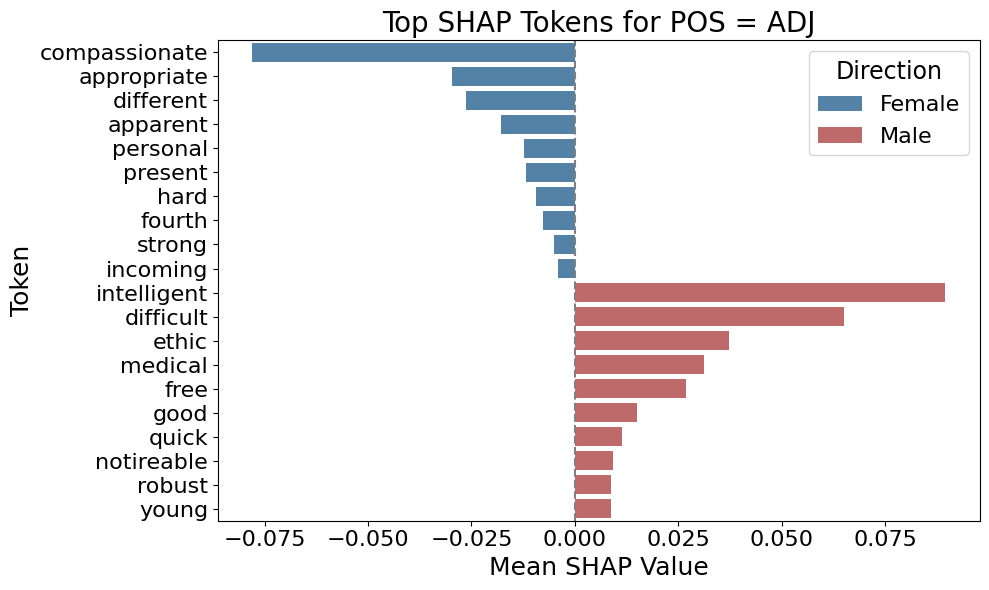

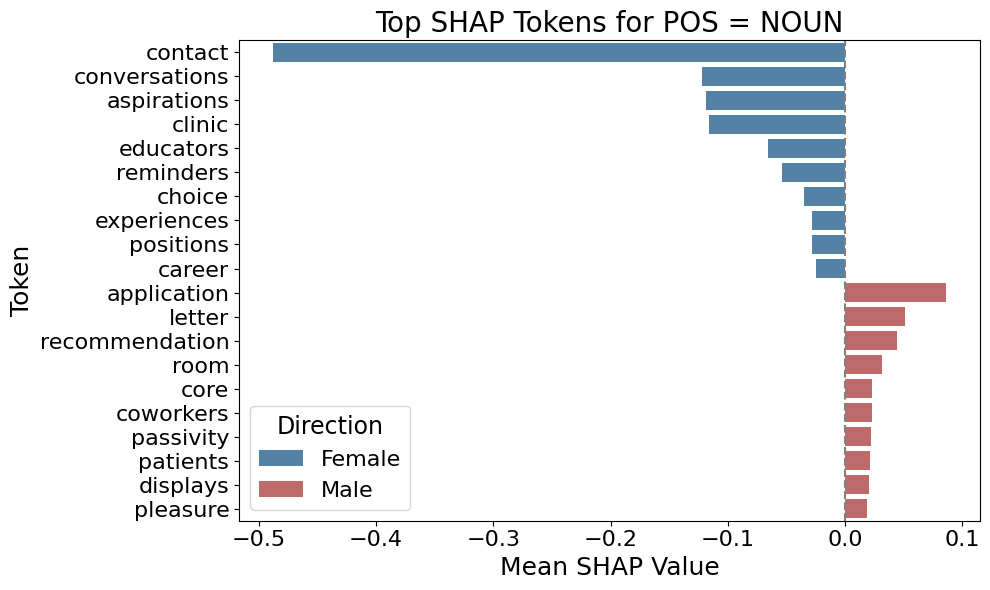

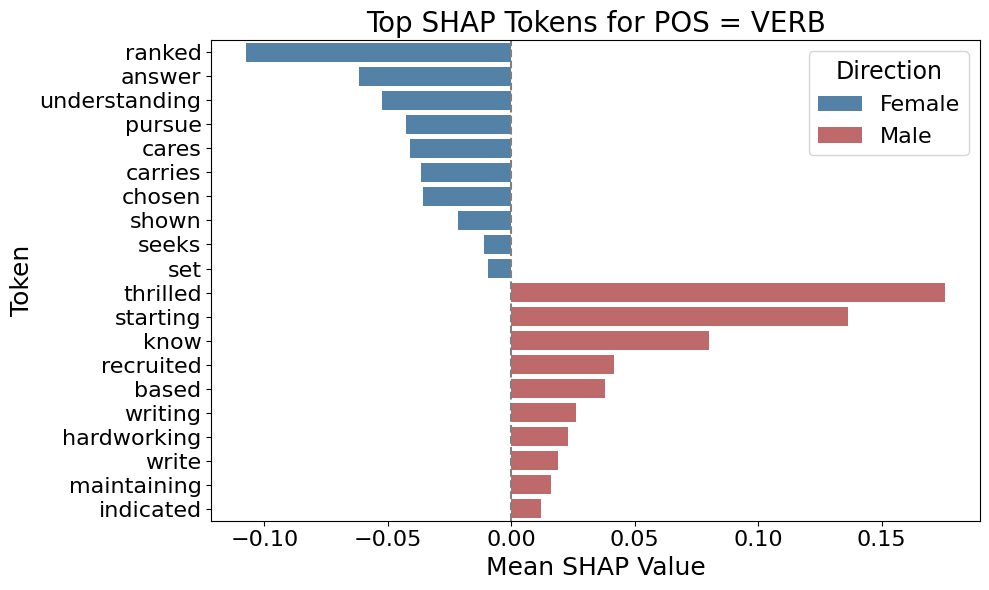

In [64]:
# adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10, save_path=f'../cleaned_figures/{model_name}_adj_shap_chart.png')
# noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10, save_path=f'../cleaned_figures/{model_name}_noun_shap_chart.png')
# verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10, save_path=f'../cleaned_figures/{model_name}_verb_shap_chart.png')

adj_male, adj_female = plot_top_shap_by_pos(df_filtered, "ADJ", top_n=10)
noun_male, noun_female = plot_top_shap_by_pos(df_filtered, "NOUN", top_n=10)
verb_male, verb_female = plot_top_shap_by_pos(df_filtered, "VERB", top_n=10)



# Create Dataset With Implicit Gendered Tokens Removed - SHAP

In [65]:
all_tokens

# Optional: save if needed
# all_tokens.to_csv(f"../cleaned_data/shap_tokens/top_tokens_shap_{model_name}.csv", index=False)

,token
0,intelligent
1,difficult
2,ethic
3,medical
4,free
5,good
6,quick
7,notireable
8,robust
9,complete


In [66]:
import pandas as pd
from transformers import AutoTokenizer
import re

# Load RoBERTa tokenizer
# tokenizer = AutoTokenizer.from_pretrained("../saved_models/merged_llama2_classifier")
mask_token = tokenizer.unk_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [67]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [68]:
df

,full_text,label
0,it is my <unk> to <unk> a <unk> of <unk...,0
1,i am pleased to highly recommend identifier fo...,0
2,i am <unk> this <unk> in support of identi...,0
3,identifier identifier recently <unk> d an ane...,0
4,it is my <unk> to recommend dr. identifier f...,0
...,...,...
8982,it is with <unk> that i recommend first_name...,0
8983,we are very pleased to <unk> this <unk> <...,0
8984,i am <unk> this <unk> of <unk> for first...,1
8985,it is my <unk> to <unk> first_name support...,1


In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_shap_tokens_removed.csv", index=False)


# Create Dataset With Implicit Gendered Tokens Removed - TFIDF

In [ ]:
all_tokens_df = pd.read_csv('../data/top_tokens_tfidf.csv')
all_tokens = all_tokens_df['token']

In [ ]:
import pandas as pd
from transformers import AutoTokenizer
import re

tokenizer = AutoTokenizer.from_pretrained("../saved_models/final_roberta_degendered_model")
mask_token = tokenizer.unk_token  # '<mask>'

# Token list
token_list = all_tokens.tolist()

# Escape special regex characters
escaped_tokens = [re.escape(token) for token in token_list]
pattern = "(" + "|".join(escaped_tokens) + ")"

# Replace matches with spaced mask token
def mask_text(text):
    return re.sub(pattern, f" {mask_token} ", text)


In [ ]:
df = pd.read_csv('../data/combined_letters_degendered.csv')
# Apply the masking
df["full_text"] = df["full_text"].apply(mask_text)

In [ ]:
df

,full_text,label
0,it is my pleasure to write a letter of recomme...,0
1,i am pleased to highly recommend <unk> for a...,0
2,i am writing this letter in <unk> of <unk> ...,0
3,<unk> <unk> recently <unk> d an <unk> ...,0
4,it is my pleasure to recommend dr. <unk> for...,0
...,...,...
8982,it is with pleasure that i recommend first_nam...,0
8983,we are very pleased to write this letter based...,0
8984,i am writing this letter of recommendation for...,1
8985,it is my pleasure to write first_name <unk> ...,1


In [ ]:
# df.to_csv(f"../cleaned_data/implicit_degendered_data/combined_letters_degendered_{model_name}_tfidf_tokens_removed.csv", index=False)
